In [20]:
# Imports and configuration
import os, re, glob
import json
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from rasterstats import zonal_stats
import rasterio

# load project config if present
config_path = Path('config.json')
if config_path.exists():
    with open(config_path, 'r') as f:
        config = json.load(f)
    data_processed = Path(config['paths'].get('data_processed', 'Data/Processed'))
    figures_path = Path(config['paths'].get('figures', 'Outputs/Figures'))
else:
    data_processed = Path('Data/Processed')
    figures_path = Path('Outputs/Figures')

# neighborhoods vector used for zonal stats
neigh_fp = data_processed / 'neighborhoods_final.gpkg'
if not neigh_fp.exists():
    raise FileNotFoundError(f'Neighborhood file not found: {neigh_fp}')
neigh = gpd.read_file(neigh_fp)
# replace this with your neighborhood id column name
id_col = 'geoid' if 'geoid' in neigh.columns else neigh.columns[0]

# rasters directories: support monthly/yearly time-series or 30yr normals
# Priority: look for monthly time-series, then yearly, then fall back to 30yr normals
time_series_parent = Path('Data/Raw/Climate')
possible_dirs = [
    ('prism_tmax_us_30s_monthly', 'prism_vpdmax_us_30s_monthly'),  # Monthly time-series
    ('prism_tmax_us_30s_yearly', 'prism_vpdmax_us_30s_yearly'),      # Yearly time-series
    ('prism_tmax_us_30s_2020_avg_30y', 'prism_vpdmax_us_30s_2020_avg_30y'),  # 30yr normals
]

tmax_dir = None
vpd_dir = None
for tmax_alt, vpd_alt in possible_dirs:
    cand_tmax = time_series_parent / tmax_alt
    cand_vpd = time_series_parent / vpd_alt
    if cand_tmax.exists() and cand_vpd.exists():
        tmax_tifs = list(cand_tmax.glob('*.tif'))
        vpd_tifs = list(cand_vpd.glob('*.tif'))
        if tmax_tifs and vpd_tifs:
            tmax_dir = cand_tmax
            vpd_dir = cand_vpd
            print(f'Found raster directories: {tmax_alt}, {vpd_alt}')
            break

if tmax_dir is None:
    raise FileNotFoundError('No TMAX/VPD raster directories found. Expected one of:\n' +
                            '\n'.join([f'  - {time_series_parent / dirs[0]} & {time_series_parent / dirs[1]}' for dirs in possible_dirs]))

print(f'Using: TMAX={tmax_dir.name}, VPD={vpd_dir.name}')

# Ensure neighbourhoods are in same CRS as raster (prevents huge read windows)
t0 = next(tmax_dir.glob('*.tif'), None)
if t0 is not None:
    with rasterio.open(t0) as src:
        rast_crs = src.crs
    if neigh.crs != rast_crs:
        print(f'Reprojecting neighborhoods from {neigh.crs} to {rast_crs}')
        neigh = neigh.to_crs(rast_crs)

# output
out_dir = Path('Outputs/Statistics')
out_dir.mkdir(parents=True, exist_ok=True)
out_csv = out_dir / 'neighborhood_wbgt_by_month.csv'

Found raster directories: prism_tmax_us_30s_monthly, prism_vpdmax_us_30s_monthly
Using: TMAX=prism_tmax_us_30s_monthly, VPD=prism_vpdmax_us_30s_monthly
Reprojecting neighborhoods from EPSG:2263 to EPSG:4269


In [21]:
# Helper functions for vapor pressure and WBGT approximation
def es_kpa(Tc):
    """Saturation vapor pressure (kPa) using Tetens formula
    Tc: temperature in °C
    returns: es in kPa
    """
    return 0.6108 * np.exp((17.27 * Tc) / (Tc + 237.3))


def detect_and_convert_tmax(mean_val):
    # Attempt to detect units: if very large (>100) assume Kelvin, convert to °C
    if mean_val is None:
        return None
    if mean_val > 200:  # Kelvin-like (eg 273+)
        return mean_val - 273.15
    return mean_val


def detect_and_convert_vpd(mean_val):
    # VPD typical ranges: kPa ~0-4, hPa ~0-40, Pa ~0-4000. Convert to kPa.
    if mean_val is None:
        return None
    if mean_val > 100:
        # treat as Pa -> kPa
        return mean_val / 1000.0
    if mean_val > 10:
        # treat as hPa -> kPa
        return mean_val / 10.0
    # otherwise assume already kPa
    return mean_val


def detect_and_convert_solar(mean_val):
    """Try to infer solar-radiation units and convert to kW/m^2.

    - If values look like MJ/m2/day (typical monthly totals <= ~50) convert to kW/m2
      using: 1 MJ/m2/day ≈ 11.574 W/m2 => 0.011574 kW/m2
    - If values are larger (tens to thousands) treat as W/m2 and convert to kW/m2
    - Returns float (kW/m2) or None
    """
    if mean_val is None:
        return None
    mv = float(mean_val)
    # MJ/m2/day (monthly normals often in this range)
    if mv <= 50:
        return mv * 0.011574
    # otherwise assume W/m2
    return mv / 1000.0


def compute_wbgt(Tc, vpd_kpa):
    """Baseline regression WBGT approximation used previously.
    Returns: (wbgt_C, ea_kPa)
    """
    es = es_kpa(Tc)
    ea = es - vpd_kpa
    ea = max(ea, 0.001)
    wbgt = 0.567 * Tc + 0.393 * ea + 3.94
    return wbgt, ea


def compute_wbgt_enhanced(Tc, vpd_kpa, solar_kw_m2=None, cloud_trans=1.0, rad_coeff=3.0):
    """Enhanced WBGT: starts from baseline regression and applies a simple
    radiation adjustment when solar irradiance is available.

    - solar_kw_m2: incoming solar in kW/m^2 (optional)
    - cloud_trans: fraction [0-1] to attenuate solar (default 1.0)
    - rad_coeff: empirical coefficient (degC per kW/m^2)

    This is an empirical adjustment (keeps existing baseline when solar is not
    available). Tweak `rad_coeff` if you have validation data.
    """
    wbgt_base, ea = compute_wbgt(Tc, vpd_kpa)
    if solar_kw_m2 is None:
        return wbgt_base, ea
    # radiation adjustment (empirical)
    rad_adj = rad_coeff * solar_kw_m2 * float(cloud_trans)
    return wbgt_base + rad_adj, ea


In [22]:
def extract_period(fname):
    """Infer period string from a raster filename.

    Returns:
      - 'YYYY-MM' for monthly files
      - 'YYYY'     for yearly files
      - '30yr_normal' for 30-year normals
      - ''         if no period detected
    """
    s = str(fname)
    s_low = s.lower()

    # 1) Prefer explicit YYYY-MM / YYYYMM tokens (covers monthly 30-yr normals too)
    m = re.search(r"(\d{4})[-_]?([0-1][0-9])", s)
    if m:
        year, mon = m.group(1), m.group(2)
        mi = int(mon)
        if 1 <= mi <= 12:
            return f"{year}-{mon}"

    # 2) month name tokens (e.g. 'jan','feb')
    months = {
        'jan': '01','feb': '02','mar': '03','apr': '04','may': '05','jun': '06',
        'jul': '07','aug': '08','sep': '09','oct': '10','nov': '11','dec': '12'
    }
    for k, v in months.items():
        if re.search(rf"\b{k}\b", s_low):
            y = re.search(r"(\d{4})", s)
            return (f"{y.group(1)}-{v}" if y else f"{v}")

    # 3) explicit 30-year normal indicator (no month token present)
    if re.search(r"30y|avg_30y|30-yr", s_low):
        return '30yr_normal'

    # 4) fallback: any 4-digit year
    y = re.search(r"(\d{4})", s)
    if y:
        return y.group(1)

    return ''

In [23]:
# Diagnostic: inspect raster and neighborhood metadata
print('TMAX files found:', len(tmax_files), ' — sample:', tmax_files[:3])
print('VPD  files found:', len(vpd_files),  ' — sample:', vpd_files[:3])

if tmax_files:
    import rasterio
    t0 = tmax_files[0]
    with rasterio.open(t0) as src:
        print('\nTMAX raster info:')
        print(' path:', t0)
        print(' driver:', src.driver)
        print(' dtype:', src.dtypes)
        print(' width x height:', src.width, 'x', src.height)
        print(' bounds:', src.bounds)
        print(' crs:', src.crs)
        print(' count (bands):', src.count)
        print(' transform:', src.transform)
        print(' filesize (MB):', round((Path(t0).stat().st_size / 1024**2), 1))

print('\nNeighborhoods:')
print(' count:', len(neigh))
print(' crs:', neigh.crs)
print(' total bounds:', neigh.total_bounds)
print(' sample geometry bounds (first):', neigh.geometry.iloc[0].bounds)


TMAX files found: 13  — sample: ['Data\\Raw\\Climate\\prism_tmax_us_30s_monthly\\prism_tmax_us_30s_202001_avg_30y.tif', 'Data\\Raw\\Climate\\prism_tmax_us_30s_monthly\\prism_tmax_us_30s_202002_avg_30y.tif', 'Data\\Raw\\Climate\\prism_tmax_us_30s_monthly\\prism_tmax_us_30s_202003_avg_30y.tif']
VPD  files found: 13  — sample: ['Data\\Raw\\Climate\\prism_vpdmax_us_30s_monthly\\prism_vpdmax_us_30s_202001_avg_30y.tif', 'Data\\Raw\\Climate\\prism_vpdmax_us_30s_monthly\\prism_vpdmax_us_30s_202002_avg_30y.tif', 'Data\\Raw\\Climate\\prism_vpdmax_us_30s_monthly\\prism_vpdmax_us_30s_202003_avg_30y.tif']

TMAX raster info:
 path: Data\Raw\Climate\prism_tmax_us_30s_monthly\prism_tmax_us_30s_202001_avg_30y.tif
 driver: GTiff
 dtype: ('float32',)
 width x height: 7025 x 3105
 bounds: BoundingBox(left=-125.02083333335, bottom=24.06250010345, right=-66.47916690085, top=49.93749999995)
 crs: EPSG:4269
 count (bands): 1
 transform: | 0.01, 0.00,-125.02|
| 0.00,-0.01, 49.94|
| 0.00, 0.00, 1.00|
 filesize 

In [24]:
# Main processing: iterate tmax rasters, find matching vpd (and optional solar) rasters,
# compute zonal means and WBGT
# Get list of files
tmax_files = sorted([p for p in glob.glob(str(tmax_dir / '*.tif'))])
vpd_files  = sorted([p for p in glob.glob(str(vpd_dir  / '*.tif'))])

# attempt to locate an optional solar-radiation directory (matches sol*, solar, or srad)
solar_dir = None
solar_files = []
for p in time_series_parent.iterdir():
    # PRISM uses names like 'soltotal', 'soltrans', 'solclear' and sometimes 'srad' or 'solar'
    # match directories that contain 'sol' anywhere in the name as well as 'solar'/'srad'
    if p.is_dir() and ('sol' in p.name.lower() or 'solar' in p.name.lower() or 'srad' in p.name.lower()):
        sf = list(p.glob('*.tif'))
        if sf:
            solar_dir = p
            solar_files = sorted([str(x) for x in sf])
            print('Found solar-radiation directory:', solar_dir.name)
            break

# quick pairing helper: try predictable name conversions
def find_vpd_for_tmax(tpath):
    tname = os.path.basename(tpath)
    # 1) try exact stem replacement (tmax -> vpdmax)
    cand = vpd_dir / tname.replace('tmax', 'vpdmax')
    if cand.exists():
        return str(cand)
    # 2) try replacing known prefixes
    cand = vpd_dir / tname.replace('prism_tmax', 'prism_vpdmax')
    if cand.exists():
        return str(cand)
    # 3) try to find any vpd file that shares a common date substring
    for vf in vpd_files:
        if os.path.splitext(os.path.basename(vf))[0].split('_')[-2:] == os.path.splitext(tname)[0].split('_')[-2:]:
            return vf
    # 4) fallback: if only one vpd file exists, return it
    if len(vpd_files) == 1:
        return vpd_files[0]
    return None


def find_solar_for_tmax(tpath):
    if solar_dir is None:
        return None
    tname = os.path.basename(tpath)
    # try replacing known tokens (cover srad, soltotal, soltrans)
    candidates = [
        tname.replace('tmax', 'srad'),
        tname.replace('prism_tmax', 'prism_srad'),
        tname.replace('tmax', 'soltotal'),
        tname.replace('prism_tmax', 'prism_soltotal'),
        tname.replace('tmax', 'soltrans'),
        tname.replace('prism_tmax', 'prism_soltrans'),
    ]
    for c in candidates:
        cand = solar_dir / c
        if cand.exists():
            return str(cand)
    # try to match by date substring
    for sf in solar_files:
        if os.path.splitext(os.path.basename(sf))[0].split('_')[-2:] == os.path.splitext(tname)[0].split('_')[-2:]:
            return sf
    # fallback
    if len(solar_files) == 1:
        return solar_files[0]
    return None

rows = []

# Build pairs (and optional solar match). If both directories contain exactly one raster each,
# treat as an "annual" pair (and attach solar if present).
if len(tmax_files) == 1 and len(vpd_files) == 1:
    single_t = tmax_files[0]
    single_v = vpd_files[0]
    single_s = find_solar_for_tmax(single_t)
    pairs = [(single_t, single_v, single_s)]
else:
    pairs = []
    for tpath in tmax_files:
        vmatch = find_vpd_for_tmax(tpath)
        if vmatch is None:
            print(f'No VPD match for {os.path.basename(tpath)}, skipping')
            continue
        smatch = find_solar_for_tmax(tpath)
        pairs.append((tpath, vmatch, smatch))

if not pairs:
    print('No matching Tmax/VPD raster pairs found — nothing to process.')
else:
    for tpath, vpath, spath in pairs:
        tname = os.path.basename(tpath)
        vname = os.path.basename(vpath)
        sname = os.path.basename(spath) if spath else None

        # compute zonal mean for tmax, vpd, (and solar if available)
        t_stats = zonal_stats(neigh, tpath, stats=['mean'], all_touched=True, nodata=None)
        v_stats = zonal_stats(neigh, vpath,  stats=['mean'], all_touched=True, nodata=None)
        s_stats = zonal_stats(neigh, spath,  stats=['mean'], all_touched=True, nodata=None) if spath else [None]*len(neigh)

        for i, geom in neigh.iterrows():
            t_mean = t_stats[i].get('mean') if t_stats[i] else None
            v_mean = v_stats[i].get('mean') if v_stats[i] else None
            s_mean = s_stats[i].get('mean') if s_stats and s_stats[i] else None

            if t_mean is None or v_mean is None:
                wbgt = np.nan
                ea = np.nan
                t_c = None
                v_kpa = None
                s_kw = None
            else:
                t_c = detect_and_convert_tmax(t_mean)
                v_kpa = detect_and_convert_vpd(v_mean)
                s_kw = detect_and_convert_solar(s_mean) if s_mean is not None else None

                if t_c is None or v_kpa is None:
                    wbgt = np.nan; ea = np.nan
                else:
                    if s_kw is not None:
                        wbgt, ea = compute_wbgt_enhanced(t_c, v_kpa, solar_kw_m2=s_kw)
                    else:
                        wbgt, ea = compute_wbgt(t_c, v_kpa)

            rows.append({
                id_col: geom[id_col],
                'raster_file': tname,
                'vpd_file': vname,
                'solar_file': sname,
                'tmax_mean_raw': t_mean,
                'tmax_mean_C': t_c,
                'vpd_mean_raw': v_mean,
                'vpd_mean_kPa': v_kpa,
                'solar_mean_raw': s_mean,
                'solar_mean_kW_m2': s_kw,
                'ea_kPa': ea,
                'wbgt_C': wbgt
            })

# build DataFrame and add period/year/month where available
if not rows:
    print('No neighborhood statistics were produced (rows is empty).')
    df = pd.DataFrame(rows)
else:
    df = pd.DataFrame(rows)
    
    # Enhanced period detection is unchanged (keeps YYYY-MM / YYYY / 30yr_normal)
    if 'raster_file' in df.columns:
        df['period'] = df['raster_file'].fillna('').apply(extract_period)
        df['year'] = df['period'].str.extract(r'(\d{4})', expand=False)
        df['month'] = df['period'].str.extract(r'-(\d{2})', expand=False)

    df.to_csv(out_csv, index=False)
    print('Saved WBGT CSV to', out_csv)
    print('Rows written:', len(df), ' — sample:')
    print(df.head().to_string(index=False))
    print('\nUnique periods found:')
    print(df['period'].unique())

Found solar-radiation directory: prism_soltotal_us_30s_monthly
Saved WBGT CSV to Outputs\Statistics\neighborhood_wbgt_by_month.csv
Rows written: 3406  — sample:
 GEOID                          raster_file                               vpd_file                               solar_file  tmax_mean_raw  tmax_mean_C  vpd_mean_raw  vpd_mean_kPa  solar_mean_raw  solar_mean_kW_m2  ea_kPa   wbgt_C  period year month
BK0101 prism_tmax_us_30s_202001_avg_30y.tif prism_vpdmax_us_30s_202001_avg_30y.tif prism_soltotal_us_30s_202001_avg_30y.tif       4.289367     4.289367      4.088617      4.088617        6.416417          0.074264   0.001 6.595255 2020-01 2020    01
BK0102 prism_tmax_us_30s_202001_avg_30y.tif prism_vpdmax_us_30s_202001_avg_30y.tif prism_soltotal_us_30s_202001_avg_30y.tif       4.314500     4.314500      4.097500      4.097500        6.443333          0.074575   0.001 6.610440 2020-01 2020    01
BK0103 prism_tmax_us_30s_202001_avg_30y.tif prism_vpdmax_us_30s_202001_avg_30y.tif prism_

In [25]:
# Export neighborhood centroids as a PRISM 'locations' CSV (lat,lon,optional name <=12 chars)
locs_fp = Path('Data/Processed/prism_locations_neighborhoods.csv')

# ensure geographic coords
neigh_latlon = neigh.to_crs(epsg=4326).copy()
centroids = neigh_latlon.geometry.centroid

# prefer a short name column if available, else use the id_col
short_name = None
for candidate in ['name', 'Name', 'neighborhood', 'nbhd', id_col]:
    if candidate in neigh_latlon.columns:
        short_name = neigh_latlon[candidate].astype(str).str.slice(0,12)
        break

df_locs = pd.DataFrame({
    'latitude': centroids.y,
    'longitude': centroids.x,
    'name': short_name if short_name is not None else neigh_latlon[id_col].astype(str).str.slice(0,12)
})

df_locs.to_csv(locs_fp, index=False)
print('Wrote PRISM locations file:', locs_fp)
print('Sample (first 6 rows):')
print(df_locs.head(6).to_string(index=False))

# Quick upload instructions for PRISM Data Explorer
print('\nUpload this CSV to: https://prism.oregonstate.edu/explorer/bulk.php')
print('CSV format: latitude,longitude,optional-name (<=12 chars). Use 4km or 800m and request "Solar rad (horiz sfc)" for monthly normals.')

Wrote PRISM locations file: Data\Processed\prism_locations_neighborhoods.csv
Sample (first 6 rows):
 latitude  longitude   name
40.729500 -73.949517 BK0101
40.714914 -73.958621 BK0102
40.703242 -73.956659 BK0103
40.713300 -73.936488 BK0104
40.695466 -73.994830 BK0201
40.694900 -73.985830 BK0202

Upload this CSV to: https://prism.oregonstate.edu/explorer/bulk.php
CSV format: latitude,longitude,optional-name (<=12 chars). Use 4km or 800m and request "Solar rad (horiz sfc)" for monthly normals.


C:\Users\Jackson\AppData\Local\Temp\ipykernel_13000\1793234188.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = neigh_latlon.geometry.centroid


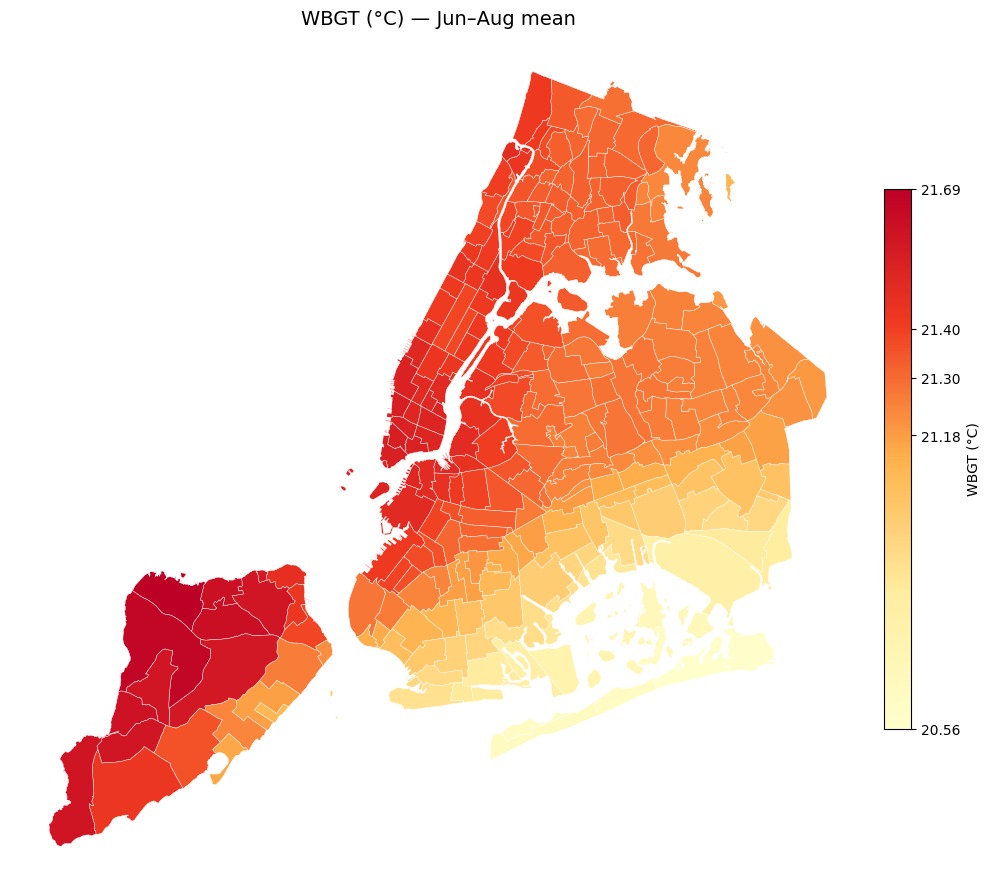

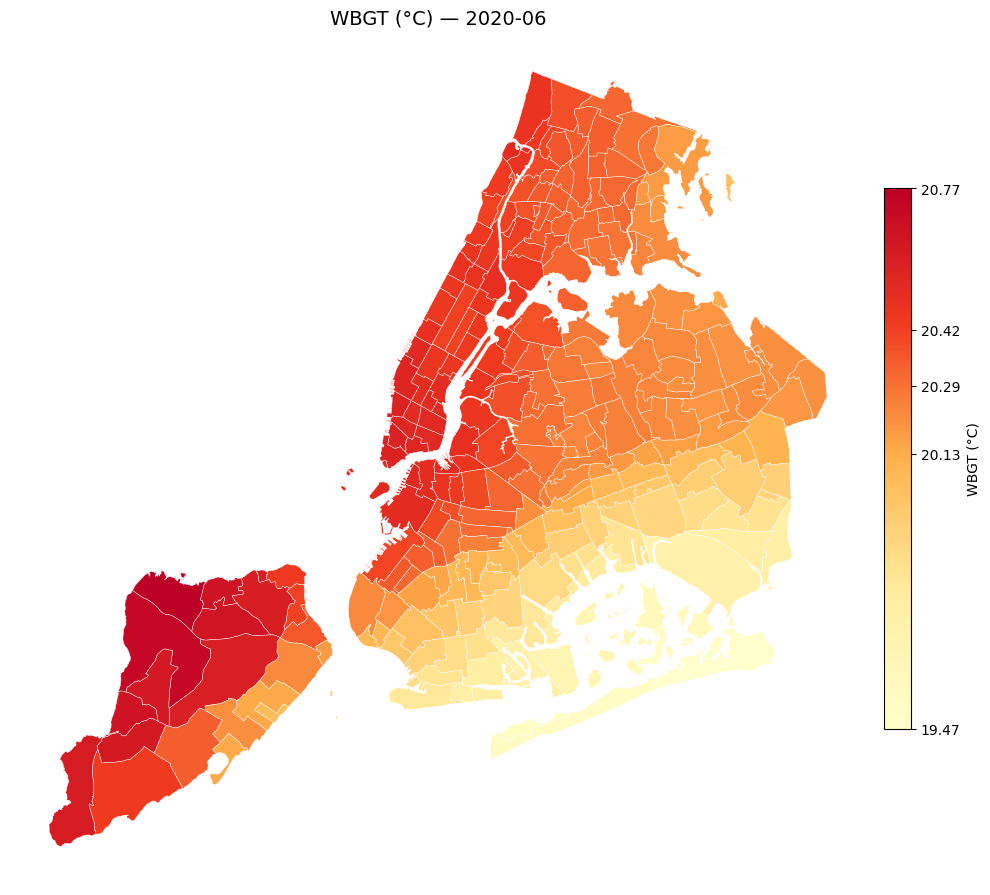

Max absolute difference (recomputed vs stored): 1.0658141036401503e-14

Formula used:
  WBGT_baseline = 0.567 * T_c + 0.393 * ea + 3.94
  where ea = es(T_c) - VPD_kPa ; es(T_c) = 0.6108 * exp((17.27*T_c)/(T_c+237.3))
  Enhanced: + rad_coeff * solar_kW_m2 * cloud_trans (rad_coeff default = 3.0)

Units: T_c in °C, VPD in kPa, solar in kW/m^2

Top 5 (highest) WBGT neighborhoods — 2020-08
 GEOID    wbgt_C
SI0107 21.830807
SI0204 21.804800
SI0105 21.790956
SI0106 21.772827
SI0104 21.765959


In [ ]:
# --- Visualization: WBGT choropleth (emphasize disparities) ---
import matplotlib.pyplot as plt
import matplotlib as mpl

# read the WBGT CSV (use notebook variable if present)
wbgt_path = out_csv if 'out_csv' in locals() else Path('Outputs/Statistics/neighborhood_wbgt_by_month.csv')
wbgt_df = pd.read_csv(wbgt_path)
if 'GEOID' not in wbgt_df.columns and id_col in wbgt_df.columns:
    wbgt_df = wbgt_df.rename(columns={id_col: 'GEOID'})

# monthly periods (exclude 30yr_normal)
periods = sorted([p for p in wbgt_df['period'].unique() if p != '30yr_normal'])
if not periods:
    raise RuntimeError('No monthly periods found in WBGT CSV')

# compute dispersion (std) but DO NOT print it here (kept for internal selection)
disp = (wbgt_df[wbgt_df['period'].isin(periods)]
        .groupby('period')['wbgt_C']
        .agg(['std','max','min']).assign(range=lambda x: x['max'] - x['min']))
max_disp_period = disp['std'].idxmax()

# create a smooth yellow->red continuous colormap for all maps
yellow_red_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'yellow_red', ['#ffffcc', '#ffeda0', '#feb24c', '#f03b20', '#bd0026']
)


def plot_wbgt_for_period(period, out_name_suffix, continuous=True, cmap=yellow_red_cmap):
    """Plot WBGT for a single period using a continuous yellow->red colormap.
       - continuous=True plots a smooth gradient (no discrete bins)
       - out_name_suffix is used for the output filename
    """
    dfp = wbgt_df[wbgt_df['period'] == period][['GEOID','wbgt_C']].copy()
    g = neigh.merge(dfp, left_on=id_col, right_on='GEOID', how='left')
    vals = g['wbgt_C'].dropna()
    if vals.empty:
        return g

    vmin, vmax = float(vals.min()), float(vals.max())
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(1,1,figsize=(10,10))
    g.plot(column='wbgt_C', cmap=cmap, norm=norm, linewidth=0.3, edgecolor='white', ax=ax,
           missing_kwds={'color':'lightgrey','hatch':'///','label':'no data'})
    ax.axis('off')
    ax.set_title(f'WBGT (°C) — {period}', fontsize=14)

    # show continuous colorbar with helpful tick marks (quantiles)
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    ticks = np.quantile(vals, [0.0, 0.25, 0.5, 0.75, 1.0])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, ticks=ticks)
    cbar.set_label('WBGT (°C)')
    cbar.ax.set_yticklabels([f"{t:.2f}" for t in ticks])

    out_fp = Path(f'Outputs/Figures/wbgt_choropleth_{out_name_suffix}.png')
    out_fp.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(out_fp, dpi=150)
    plt.show()
    return g

# disparity map generation removed per user request

# Jun–Aug mean (continuous yellow->red)
summer_months = {'06','07','08'}
summer_periods = [p for p in periods if p.split('-')[1] in summer_months]
if summer_periods:
    summer_df = wbgt_df[wbgt_df['period'].isin(summer_periods)].groupby('GEOID', as_index=False)['wbgt_C'].mean()
    g_summer = neigh.merge(summer_df, left_on=id_col, right_on='GEOID', how='left')
    _ = plot_wbgt_for_period('summer_mean', 'summer_mean', continuous=True) if False else None
    fig, ax = plt.subplots(1,1,figsize=(10,10))
    vals = g_summer['wbgt_C'].dropna()
    if not vals.empty:
        vmin, vmax = float(vals.min()), float(vals.max())
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        g_summer.plot(column='wbgt_C', cmap=yellow_red_cmap, norm=norm, linewidth=0.3, edgecolor='white', ax=ax,
                      missing_kwds={'color':'lightgrey','hatch':'///','label':'no data'})
        ax.axis('off')
        ax.set_title('WBGT (°C) — Jun–Aug mean', fontsize=14)
        sm = mpl.cm.ScalarMappable(cmap=yellow_red_cmap, norm=norm)
        sm._A = []
        ticks = np.quantile(vals, [0.0,0.25,0.5,0.75,1.0])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, ticks=ticks)
        cbar.set_label('WBGT (°C)')
        cbar.ax.set_yticklabels([f"{t:.2f}" for t in ticks])
        out_fp2 = Path('Outputs/Figures/wbgt_choropleth_summer_mean.png')
        out_fp2.parent.mkdir(parents=True, exist_ok=True)
        fig.tight_layout(); fig.savefig(out_fp2, dpi=150); plt.show()

period_stats = (wbgt_df[wbgt_df['period'] != '30yr_normal']
                .groupby('period')['wbgt_C']
                .agg(['count','mean','std','min','max']))

candidates = period_stats[period_stats['mean'] >= 20.0].copy()
if candidates.empty:
    chosen_20s = period_stats['mean'].idxmax()
else:
    chosen_20s = candidates['std'].idxmax()

# Plot the chosen period with a smooth yellow->red gradient (no printed message)
g_20s = plot_wbgt_for_period(chosen_20s, f"{chosen_20s.replace('-','')}_20s_disp", continuous=True)